In [ ]:
#Loading FlauBERT model and tokenizer
from transformers import AutoTokenizer, AutoModel
MODEL_NAME = 'flaubert/flaubert_base_cased' #Specification of the base model to be used 

try:
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) #Loading the tokeniser from the specified model
    print("✅ FlauBERT tokeniser successfully loaded.")

   #Load the model using AutoModel, which loads its architecture to obtain embeddings. 
    model = AutoModel.from_pretrained(MODEL_NAME)
    print("✅ FlauBERT model successfully loaded (Architecture and Weight).")
    
    # Configuration Verification
    print(f"\nConfiguration : {model.config.vocab_size} tokens in the vocabulary.")

except Exception as e:
    print(f"❌ Error loading FlauBERT: {e}")
    print("Make sure you are connected to the Internet and that 'transformers' is properly installed.")

✅ Tokenizer FlauBERT chargé avec succès.
✅ Modèle FlauBERT chargé avec succès (Architecture et Poids).

Configuration : 68729 tokens dans le vocabulaire.


In [ ]:
#First cosine similarity example
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

#Load the tokenizer and model
model_name = "flaubert/flaubert_base_cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Function to get the embedding of a sentence
def get_embedding(sentence):
    inputs = tokenizer(sentence, return_tensors="pt")
    outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :]

def similarity(s1, s2):
    emb1, emb2 = get_embedding(s1), get_embedding(s2)
    cos = F.cosine_similarity(emb1, emb2)
    return float(cos)

pairs = [
    ("Je suis fatigué", "J’suis claqué frère"),
    ("Je vais à l’école", "j’vais au bahut wsh"),
    ("C’est incroyable", "c’est trop d’art mdrrr"),
    ("Je ne comprends pas", "j’capte rien ptdrr"),
]

for f1, f2 in pairs:
    print(f"{f1}  ↔  {f2}  → cosine similarity = {similarity(f1, f2):.3f}")


Je suis fatigué  ↔  J’suis claqué frère  → similarity = 0.156
Je vais à l’école  ↔  j’vais au bahut wsh  → similarity = 0.099
C’est incroyable  ↔  c’est trop d’art mdrrr  → similarity = 0.764
Je ne comprends pas  ↔  j’capte rien ptdrr  → similarity = 0.802


C:\Users\Bryan\AppData\Local\Temp\ipykernel_29628\3731792686.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(cos)


In [ ]:
#Script to assign similarity scores based on predefined rules and save to CSV / à ne pas utiliser pour le moment
import pandas as pd

# Function for assigning similarity scores based rules
def assign_similarity_score(sentence1, sentence2):

    if sentence1 == sentence2:
        return 5
    elif sentence1.lower() in sentence2.lower() or sentence2.lower() in sentence1.lower():
        return 4
    elif len(set(sentence1.split()).intersection(set(sentence2.split()))) > 0:
        return 3
    elif set(sentence1.split()) != set(sentence2.split()):
        return 2
    elif sentence1.split()[0] == sentence2.split()[0]:
        return 1
    else:
        return 0


dataset = pd.read_csv('STS_dataset_empty.csv')

# Ensure that the columns 'sentence1' and 'sentence2' exist in the dataset
if 'sentence1' not in dataset.columns or 'sentence2' not in dataset.columns:
    raise ValueError("The columns 'sentence1' and 'sentence2' must exist in the dataset")

# Create a new column 'similarity_score' by assigning a score based on the rules
dataset['similarity_score'] = dataset.apply(lambda row: assign_similarity_score(row['sentence1'], row['sentence2']), axis=1)

# Save the new dataset with the scores
dataset.to_csv('STS_dataset.csv', index=False)

# Display a sample of the result
print(dataset.head())

In [2]:
# Correct STS score generation using cosine similarity and scaling 0–5
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

# -----------------------------
# 1. Load your model (DAFT model preferably)
# -----------------------------
MODEL_PATH = "./flaubert_daft_final"   # change if needed

print("Loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModel.from_pretrained(MODEL_PATH)
model.eval()

# -----------------------------
# 2. Function to compute embeddings
# -----------------------------
def get_embedding(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    # mean pooling to get sentence embedding
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embedding

# -----------------------------
# 3. Cosine similarity function
# -----------------------------
def cosine_sim(vec1, vec2):
    return torch.nn.functional.cosine_similarity(vec1, vec2, dim=0).item()

# -----------------------------
# 4. Convert cosine similarity [-1, 1] → STS scale [0, 5]
# -----------------------------
def cosine_to_sts(cos_sim):
    # Normalize to [0, 1]
    normalized = (cos_sim + 1) / 2
    # Scale to [0, 5]
    return round(normalized * 5, 3)

# -----------------------------
# 5. Load data

df = pd.read_csv("STS_dataset_empty.csv", sep=";", on_bad_lines='skip', encoding="utf-8")

if 'sentence1' not in df.columns or 'sentence2' not in df.columns:
    raise ValueError("Both sentence1 and sentence2 columns must exist in the dataset.")

# -----------------------------
# 6. Compute STS score for each pair
# -----------------------------
scores = []
print("Computing similarity scores...")

for s1, s2 in zip(df["sentence1"], df["sentence2"]):

    try:
        emb1 = get_embedding(str(s1))
        emb2 = get_embedding(str(s2))

        cos = cosine_sim(emb1, emb2)
        sts_score = cosine_to_sts(cos)

        scores.append(sts_score)

    except Exception as e:
        print("Error on:", s1, "|", s2, "|", e)
        scores.append(0)

df["similarity_score"] = scores

# -----------------------------
# 7. Save final STS dataset
# -----------------------------
df.to_csv("STS_dataset_ws.csv", index=False)
print("\nDone. Saved as STS_dataset_ws.csv")
print(df.head())


Loading model and tokenizer...
Computing similarity scores...

Done. Saved as STS_dataset_ws.csv
             sentence1             sentence2  similarity_score
0    wsh t'es relou fr     t'es barbant mec              4.671
1   j'suis éclaté wsh   g ss fatigué de fou              4.575
2    j'ai zappé le rdv   Désolée j'ai oublie             4.610
3  j'arrive dans 5 min        jariv dan 5min             4.653
4          j’me taille            j’me casse             4.786


In [ ]:
# ===========================================
# Automatic STS scoring using your fine-tuned model
# ===========================================

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -----------------------------
# SETTINGS
# -----------------------------
MODEL_PATH = "./flaubert_sts_final"         # ton modèle fine-tuné STS
INPUT_FILE = "sts_pairs_to_annotate.csv"    # fichier contenant sentence1 / sentence2
OUTPUT_FILE = "sts_pairs_annotated.csv"     # fichier final annoté
MAX_LENGTH = 128

# -----------------------------
# LOAD MODEL + TOKENIZER
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

# -----------------------------
# LOAD PAIRS
# -----------------------------
print("Loading dataset...")
df = pd.read_csv(INPUT_FILE)

df.columns = df.columns.str.lower().str.strip()

if not {"sentence1", "sentence2"}.issubset(df.columns):
    raise ValueError("Dataset must contain 'sentence1' and 'sentence2' columns")

df["sentence1"] = df["sentence1"].astype(str)
df["sentence2"] = df["sentence2"].astype(str)

# -----------------------------
# SCORING FUNCTION
# -----------------------------
def predict_sts_score(s1, s2):
    inputs = tokenizer(
        s1, s2,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        score = outputs.logits.squeeze().item()

    # clamp between 0 and 5
    return max(0, min(5, score))

# -----------------------------
# PREDICT ALL SCORES
# -----------------------------
print("Generating STS scores...")
df["similarity_score"] = df.apply(
    lambda row: predict_sts_score(row["sentence1"], row["sentence2"]),
    axis=1
)

# -----------------------------
# SAVE OUTPUT
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")

print("\n====================================")
print("✔ Annotation STS terminée.")
print("Fichier généré :", OUTPUT_FILE)
print("====================================")


In [1]:
#cleaning the corpus for DAFT
import pandas as pd
from sklearn.model_selection import train_test_split
import re
import random
import io

#load the corpus file and set target size
FILE_PATH = "final_corpus.csv"
TARGET_SIZE = 100585

# cleaning function for the corpus

literal_emoticons = [":=)", ":D", "xD", "", ":P", ":)", ":(", ":-D", ":-)", ":-(", "<3", ":*", "=)", "=("]
emoticon_pattern = re.compile('|'.join(re.escape(e) for e in literal_emoticons), re.IGNORECASE)

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F" # Emoticons
    "\U0001F300-\U0001F5FF" # Symboles
    "\U0001F680-\U0001F6FF" # Transports
    "\U00002702-\U000027B0"
    "]+", flags=re.UNICODE
)

def clean_and_normalize(text):
    """Apply essential cleaning while preserving expressive punctuation."""
    text = str(text)
    
    # Delete emoticons/emojis
    text = emoticon_pattern.sub(' ', text)
    text = emoji_pattern.sub(r' ', text)
    
    # Cleaning unique punctuation characters (the rest is preserved for DAFT)
    text = re.sub(r'[^\w\s\?!\.]', r' ', text)
    
    # Finalization
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# load and clean the corpus

print(f"1. Loading file {FILE_PATH}...")

# Robust loading (forcing line reading to avoid delimiter errors)
try:
    with open(FILE_PATH, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    data = [line.strip() for line in lines[1:] if line.strip()] 
    df = pd.DataFrame(data, columns=['text'])
except Exception as e:
    print(f"Fatal error reading file: {e}")
    raise

# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_and_normalize)
df_final = df[df['cleaned_text'].str.len() > 1].head(TARGET_SIZE)[['cleaned_text']].rename(columns={'cleaned_text': 'text'})
N = len(df_final)

if N < TARGET_SIZE:
    print(f"WARNING: Only {N} valid sentences were found and will be used.")

# Split the dataset 80% Train / 10% Validation / 10% test pool 

# Split 1 : 80% Train, 20% Temp (Val + Test Pool)
train_data, temp_data = train_test_split(
    df_final, 
    test_size=0.2, 
    random_state=42 # Key for reproducibility
)

# Split 2 : 50% of Temp for Validation (i.e., 10% of total)
val_data, test_pool_data = train_test_split(
    temp_data, 
    test_size=0.5, 
    random_state=42
)

# Saving files

train_data[['text']].to_csv('stable_train_daft.csv', index=False, encoding='utf-8')
val_data[['text']].to_csv('stable_val_daft.csv', index=False, encoding='utf-8')

print("\n--- SUMMARY OF CREATED FILES ---")
print(f"✅ Training File (80%) : 'train_daft.csv' ({len(train_data)} lines)")
print(f"✅ Validation File (10%) : 'val_daft.csv' ({len(val_data)} lines)")
print(f"✅ Test Pool (10%) : {len(test_pool_data)} lines (Not used as evaluation is done on STS_dataset.csv)")
print("\nFiles are ready for Domain-Adaptive Fine-Tuning (MLM).")

1. Loading file final_corpus.csv...

--- SUMMARY OF CREATED FILES ---
✅ Training File (80%) : 'train_daft.csv' (80387 lines)
✅ Validation File (10%) : 'val_daft.csv' (10048 lines)
✅ Test Pool (10%) : 10049 lines (Not used as evaluation is done on STS_dataset.csv)

Files are ready for Domain-Adaptive Fine-Tuning (MLM).


In [34]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from scipy.stats import pearsonr, spearmanr

# model load 
MODEL_NAME = 'flaubert/flaubert_base_cased' 


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

In [2]:
import pandas as pd
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Load the STS test dataset
TEST_FILE = 'STS_dataset.csv' 
# Load The standard FlauBERT model (the Baseline)
MODEL_NAME = 'flaubert/flaubert_base_cased' 

#Loading the pre-trained FlauBERT model and tokenizer
print(f"Loading the base model: {MODEL_NAME}")
try:
    # AutoTokenizer and AutoModel to get embeddings (the model body)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME)
except Exception as e:
    print(f"Error loading model. Check your internet connection and the installation of transformers/torch.")
    raise

# Getting sentence embeddings

def get_sentence_embedding(sentence):
    """
    Calculate the sentence embedding using the [CLS] token vector.
    This is the standard method to obtain a sentence representation with BERT-like models.
    """
    # FlauBERT uses the [CLS] token to summarize the sentence (token at index 0)
    inputs = tokenizer(
        str(sentence), 
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Extract the [CLS] token vector (position 0) from the last hidden layer
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze()
    
    return cls_embedding.numpy().reshape(1, -1) 

# Evaluation loop

# Loading the test data ( Use semicolon ';' as delimiter)
try:
    df_test = pd.read_csv(TEST_FILE, sep=';')
except Exception as e:
    print(f"Error reading CSV. Make sure the file is properly delimited by ';'.")
    raise

true_scores = df_test['similarity_score'].tolist()
predicted_cos_similarities = []

print(f"\nStarting evaluation of {len(df_test)} pairs...")

for index, row in df_test.iterrows():
    # 1. Generate embeddings for both sentences
    E_A = get_sentence_embedding(row['sentence1'])
    E_B = get_sentence_embedding(row['sentence2'])
    
    # 2. Calculate Cosine similarity (Model score)
    cos_sim = cosine_similarity(E_A, E_B)[0][0]
    predicted_cos_similarities.append(cos_sim)

# calculate Spearman and Pearson correlations

true_scores_array = np.array(true_scores)
predicted_cos_similarities_array = np.array(predicted_cos_similarities) 

# 1. Spearman Correlation (ρ)
# Measures rank correlation
rho, p_value_rho = spearmanr(true_scores_array, predicted_cos_similarities_array)
   
# 2. Pearson Correlation (r)
# Measures linear correlation
r, p_value_r = pearsonr(true_scores_array, predicted_cos_similarities_array)

# results display

print("\n")
print("BASELINE EVALUATION RESULTS")
print(f"Key STS Metrics (503 pairs)")
print(f"Spearman Correlation (ρ) : {rho:.4f}")
print(f"Pearson Correlation (r) : {r:.4f}")

Loading the base model: flaubert/flaubert_base_cased

Starting evaluation of 503 pairs...


BASELINE EVALUATION RESULTS
Key STS Metrics (503 pairs)
Spearman Correlation (ρ) : 0.3169
Pearson Correlation (r) : 0.2611


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Load the STS test dataset
TEST_FILE = 'STS_finetuning_dataset.csv' 
# Load The standard FlauBERT model (the Baseline)
MODEL_NAME = 'flaubert/flaubert_base_cased' 

#Loading the pre-trained FlauBERT model and tokenizer
print(f"Loading the base model: {MODEL_NAME}")
try:
    # AutoTokenizer and AutoModel to get embeddings (the model body)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME)
except Exception as e:
    print(f"Error loading model. Check your internet connection and the installation of transformers/torch.")
    raise

# Getting sentence embeddings

def get_sentence_embedding(sentence):
    """
    Calculate the sentence embedding using the [CLS] token vector.
    This is the standard method to obtain a sentence representation with BERT-like models.
    """
    # FlauBERT uses the [CLS] token to summarize the sentence (token at index 0)
    inputs = tokenizer(
        str(sentence), 
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Extract the [CLS] token vector (position 0) from the last hidden layer
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze()
    
    return cls_embedding.numpy().reshape(1, -1) 

# Evaluation loop

# Loading the test data ( Use semicolon ';' as delimiter)
try:
    df_test = pd.read_csv(TEST_FILE, sep=';')
except Exception as e:
    print(f"Error reading CSV. Make sure the file is properly delimited by ';'.")
    raise

true_scores = df_test['similarity_score'].tolist()
predicted_cos_similarities = []

print(f"\nStarting evaluation of {len(df_test)} pairs...")

for index, row in df_test.iterrows():
    # 1. Generate embeddings for both sentences
    E_A = get_sentence_embedding(row['sentence1'])
    E_B = get_sentence_embedding(row['sentence2'])
    
    # 2. Calculate Cosine similarity (Model score)
    cos_sim = cosine_similarity(E_A, E_B)[0][0]
    predicted_cos_similarities.append(cos_sim)

# calculate Spearman and Pearson correlations

true_scores_array = np.array(true_scores)
predicted_cos_similarities_array = np.array(predicted_cos_similarities) 

# 1. Spearman Correlation (ρ)
# Measures rank correlation
rho, p_value_rho = spearmanr(true_scores_array, predicted_cos_similarities_array)
   
# 2. Pearson Correlation (r)
# Measures linear correlation
r, p_value_r = pearsonr(true_scores_array, predicted_cos_similarities_array)

# results display

print("\n")
print("BASELINE EVALUATION RESULTS")
print(f"Key STS Metrics (503 pairs)")
print(f"Spearman Correlation (ρ) : {rho:.4f}")
print(f"Pearson Correlation (r) : {r:.4f}")

In [3]:
print("Hello World")

Hello World


In [5]:
import pandas as pd
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Load the STS test dataset
TEST_FILE = 'STS_dataset.csv' 
# Load The standard FlauBERT model (the Baseline)
MODEL_NAME = './flaubert_daft_done' 

#Loading the pre-trained FlauBERT model and tokenizer
print(f"Loading the base model: {MODEL_NAME}")
try:
    # AutoTokenizer and AutoModel to get embeddings (the model body)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME)
except Exception as e:
    print(f"Error loading model. Check your internet connection and the installation of transformers/torch.")
    raise

# Getting sentence embeddings

def get_sentence_embedding(sentence):
    """
    Calculate the sentence embedding using the [CLS] token vector.
    This is the standard method to obtain a sentence representation with BERT-like models.
    """
    # FlauBERT uses the [CLS] token to summarize the sentence (token at index 0)
    inputs = tokenizer(
        str(sentence), 
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Extract the [CLS] token vector (position 0) from the last hidden layer
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze()
    
    return cls_embedding.numpy().reshape(1, -1) 

# Evaluation loop

# Loading the test data ( Use semicolon ';' as delimiter)
try:
    df_test = pd.read_csv(TEST_FILE, sep=';')
except Exception as e:
    print(f"Error reading CSV. Make sure the file is properly delimited by ';'.")
    raise

true_scores = df_test['similarity_score'].tolist()
predicted_cos_similarities = []

print(f"\nStarting evaluation of {len(df_test)} pairs...")

for index, row in df_test.iterrows():
    # 1. Generate embeddings for both sentences
    E_A = get_sentence_embedding(row['sentence1'])
    E_B = get_sentence_embedding(row['sentence2'])
    
    # 2. Calculate Cosine similarity (Model score)
    cos_sim = cosine_similarity(E_A, E_B)[0][0]
    predicted_cos_similarities.append(cos_sim)

# calculate Spearman and Pearson correlations

true_scores_array = np.array(true_scores)
predicted_cos_similarities_array = np.array(predicted_cos_similarities) 

# 1. Spearman Correlation (ρ)
# Measures rank correlation
rho, p_value_rho = spearmanr(true_scores_array, predicted_cos_similarities_array)
   
# 2. Pearson Correlation (r)
# Measures linear correlation
r, p_value_r = pearsonr(true_scores_array, predicted_cos_similarities_array)

# results display

print("\n")
print("BASELINE EVALUATION RESULTS")
print(f"Key STS Metrics (503 pairs)")
print(f"Spearman Correlation (ρ) : {rho:.4f}")
print(f"Pearson Correlation (r) : {r:.4f}")

Loading the base model: ./flaubert_daft_done

Starting evaluation of 503 pairs...


BASELINE EVALUATION RESULTS
Key STS Metrics (503 pairs)
Spearman Correlation (ρ) : -0.2798
Pearson Correlation (r) : -0.2361


In [8]:
import pandas as pd
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Load the STS test dataset
TEST_FILE = 'STS_dataset.csv' 
# The pre-trained FlauBERT model (the Baseline)
MODEL_NAME = './flaubert_informel' 

# --- 1. LOADING THE MODEL ---
print(f"Loading the base model: {MODEL_NAME}")
try:
    # AutoTokenizer and AutoModel to get embeddings (the model body)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME)
except Exception as e:
    print(f"Error during loading. Check your connection and the installation of transformers/torch.")
    raise

# Function to get the embedding of a sentence

def get_sentence_embedding(sentence):
    """
    Calculate the sentence embedding using the [CLS] token vector.
    This is the standard method to obtain a sentence representation with BERT-like models.
    """
    # FlauBERT uses the [CLS] token to summarize the sentence (token at index 0)
    inputs = tokenizer(
        str(sentence), 
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Extract the [CLS] token vector (position 0) from the last hidden layer
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze()
    
    return cls_embedding.numpy().reshape(1, -1) 

#STS evaluation loop

# Loading the test data (Use semicolon ';' as delimiter)
try:
    df_test = pd.read_csv(TEST_FILE, sep=';')
except Exception as e:
    print(f"Error reading CSV. Make sure the file is properly delimited by ';'.")
    raise

true_scores = df_test['similarity_score'].tolist()
predicted_cos_similarities = []

print(f"\nStarting evaluation of {len(df_test)} pairs...")

for index, row in df_test.iterrows():
    # 1. Generate embeddings for both sentences
    E_A = get_sentence_embedding(row['sentence1'])
    E_B = get_sentence_embedding(row['sentence2'])
    
    # 2. Calculate Cosine similarity (Model score)
    cos_sim = cosine_similarity(E_A, E_B)[0][0]
    predicted_cos_similarities.append(cos_sim)

# Calculate Spearman and Pearson correlations

true_scores_array = np.array(true_scores)
predicted_cos_similarities_array = np.array(predicted_cos_similarities) 

# Spearman correlation (ρ)
rho, p_value_rho = spearmanr(true_scores_array, predicted_cos_similarities_array)

# Pearson correlation (r)
r, p_value_r = pearsonr(true_scores_array, predicted_cos_similarities_array)

# Results display

print("\n")
print(" EVALUATION RESULTS")
print(f"Key STS metrics (503 pairs)")
print(f"Spearman correlation (ρ) : {rho:.4f}")
print(f"Pearson correlation (r) : {r:.4f}")

Loading the base model: ./flaubert_informel

Starting evaluation of 503 pairs...


 EVALUATION RESULTS
Key STS metrics (503 pairs)
Spearman correlation (ρ) : 0.2757
Pearson correlation (r) : 0.1795


In [9]:
import pandas as pd
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Load the STS test dataset
TEST_FILE = 'sts_finetuning_dataset.csv' 
# The pre-trained FlauBERT model (the Baseline)
MODEL_NAME = './flaubert_informel' 

# --- 1. LOADING THE MODEL ---
print(f"Loading the base model: {MODEL_NAME}")
try:
    # AutoTokenizer and AutoModel to get embeddings (the model body)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME)
except Exception as e:
    print(f"Error during loading. Check your connection and the installation of transformers/torch.")
    raise

# Function to get the embedding of a sentence

def get_sentence_embedding(sentence):
    """
    Calculate the sentence embedding using the [CLS] token vector.
    This is the standard method to obtain a sentence representation with BERT-like models.
    """
    # FlauBERT uses the [CLS] token to summarize the sentence (token at index 0)
    inputs = tokenizer(
        str(sentence), 
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Extract the [CLS] token vector (position 0) from the last hidden layer
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze()
    
    return cls_embedding.numpy().reshape(1, -1) 

#STS evaluation loop

# Loading the test data (Use semicolon ';' as delimiter)
try:
    df_test = pd.read_csv(TEST_FILE, sep=';')
except Exception as e:
    print(f"Error reading CSV. Make sure the file is properly delimited by ';'.")
    raise

true_scores = df_test['similarity_score'].tolist()
predicted_cos_similarities = []

print(f"\nStarting evaluation of {len(df_test)} pairs...")

for index, row in df_test.iterrows():
    # 1. Generate embeddings for both sentences
    E_A = get_sentence_embedding(row['sentence1'])
    E_B = get_sentence_embedding(row['sentence2'])
    
    # 2. Calculate Cosine similarity (Model score)
    cos_sim = cosine_similarity(E_A, E_B)[0][0]
    predicted_cos_similarities.append(cos_sim)

# Calculate Spearman and Pearson correlations

true_scores_array = np.array(true_scores)
predicted_cos_similarities_array = np.array(predicted_cos_similarities) 

# Spearman correlation (ρ)
rho, p_value_rho = spearmanr(true_scores_array, predicted_cos_similarities_array)

# Pearson correlation (r)
r, p_value_r = pearsonr(true_scores_array, predicted_cos_similarities_array)

# Results display

print("\n")
print(" EVALUATION RESULTS")
print(f"Key STS metrics (503 pairs)")
print(f"Spearman correlation (ρ) : {rho:.4f}")
print(f"Pearson correlation (r) : {r:.4f}")

Loading the base model: ./flaubert_informel

Starting evaluation of 9427 pairs...


 EVALUATION RESULTS
Key STS metrics (503 pairs)
Spearman correlation (ρ) : -0.2069
Pearson correlation (r) : -0.1313


In [11]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification 
import torch
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
import numpy as np
import torch.nn.functional as F 

# set parameters, datasets and paths
TEST_FILE = 'STS_dataset.csv' 
MODEL_NAME = './flaubert_informel' 

# load the fine-tuned STS model with regression head
print(f"Loading the final fine-tuned STS regression model: {MODEL_NAME}")
try:
    # Correct loading: Use AutoModelForSequenceClassification to include the REGRESSION HEAD
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME) #changement from autoModel to AutoModelForSequenceClassification
    model.eval() # turn the model to evaluation mode
except Exception as e:
    print(f"Error during loading. Please check that the folder “./flaubert_sts_final” exists.")
    raise

# Prediction function using the regression head

def get_predicted_score(sentence_a, sentence_b):
    """
    Calculate the predicted similarity score (0.0 - 5.0) directly from the model's regression head.
    """
    inputs = tokenizer(
        str(sentence_a), 
        str(sentence_b),
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
        

    predicted_score = outputs.logits.item()
    
    # Optional: Limit the score between 0 and 5 (because regression is often unconstrained)
    return np.clip(predicted_score, 0.0, 5.0) 

# running the STS evaluation
df_test = pd.read_csv(TEST_FILE, sep=';')
df_test.columns = df_test.columns.str.strip() # Clean column headers

true_scores = df_test['similarity_score'].tolist()
predicted_scores = []

print(f"\nStarting evaluation of {len(df_test)} pairs with the REGRESSION HEAD...")

for index, row in df_test.iterrows():
    # 1. Obtain the predicted score directly
    score = get_predicted_score(row['sentence1'], row['sentence2'])
    predicted_scores.append(score)

# calculating correlation metrics
true_scores_array = np.array(true_scores)
predicted_scores_array = np.array(predicted_scores) 

rho, p_value_rho = spearmanr(true_scores_array, predicted_scores_array)
r, p_value_r = pearsonr(true_scores_array, predicted_scores_array)

# displaying the final evaluation results
print("\n" )
print("Final evaluation results")
print(f"Key STS metrics ({len(df_test)} pairs)")
print(f"Correlation of Spearman (ρ) : {rho:.4f}")
print(f"Correlation of Pearson (r) : {r:.4f}")
print("this is the final result after the fine tuning" )

Loading the final fine-tuned STS regression model: ./flaubert_informel

Starting evaluation of 503 pairs with the REGRESSION HEAD...


Final evaluation results
Key STS metrics (503 pairs)
Correlation of Spearman (ρ) : 0.8420
Correlation of Pearson (r) : 0.7676
this is the final result after the fine tuning


In [12]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification 
import torch
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
import numpy as np
import torch.nn.functional as F 

# set parameters, datasets and paths
TEST_FILE = 'sts_finetuning_dataset.csv' 
MODEL_NAME = './flaubert_informel' 

# load the fine-tuned STS model with regression head
print(f"Loading the final fine-tuned STS regression model: {MODEL_NAME}")
try:
    # Correct loading: Use AutoModelForSequenceClassification to include the REGRESSION HEAD
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME) #changement from autoModel to AutoModelForSequenceClassification
    model.eval() # turn the model to evaluation mode
except Exception as e:
    print(f"Error during loading. Please check that the folder “./flaubert_sts_final” exists.")
    raise

# Prediction function using the regression head

def get_predicted_score(sentence_a, sentence_b):
    """
    Calculate the predicted similarity score (0.0 - 5.0) directly from the model's regression head.
    """
    inputs = tokenizer(
        str(sentence_a), 
        str(sentence_b),
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
        

    predicted_score = outputs.logits.item()
    
    # Optional: Limit the score between 0 and 5 (because regression is often unconstrained)
    return np.clip(predicted_score, 0.0, 5.0) 

# running the STS evaluation
df_test = pd.read_csv(TEST_FILE, sep=';')
df_test.columns = df_test.columns.str.strip() # Clean column headers

true_scores = df_test['similarity_score'].tolist()
predicted_scores = []

print(f"\nStarting evaluation of {len(df_test)} pairs with the REGRESSION HEAD...")

for index, row in df_test.iterrows():
    # 1. Obtain the predicted score directly
    score = get_predicted_score(row['sentence1'], row['sentence2'])
    predicted_scores.append(score)

# calculating correlation metrics
true_scores_array = np.array(true_scores)
predicted_scores_array = np.array(predicted_scores) 

rho, p_value_rho = spearmanr(true_scores_array, predicted_scores_array)
r, p_value_r = pearsonr(true_scores_array, predicted_scores_array)

# displaying the final evaluation results
print("\n" )
print("Final evaluation results")
print(f"Key STS metrics ({len(df_test)} pairs)")
print(f"Correlation of Spearman (ρ) : {rho:.4f}")
print(f"Correlation of Pearson (r) : {r:.4f}")
print("this is the final result after the fine tuning" )

Loading the final fine-tuned STS regression model: ./flaubert_informel

Starting evaluation of 9427 pairs with the REGRESSION HEAD...


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai



Final evaluation results
Key STS metrics (9427 pairs)
Correlation of Spearman (ρ) : 0.8126
Correlation of Pearson (r) : 0.8056
this is the final result after the fine tuning


In [ ]:
#new baseline evaluation before fine-tuning

import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# -----------------------------
# SETTINGS
# -----------------------------
MODEL_PATH = 'flaubert/flaubert_base_cased'  # Le modèle de base Flaubert pour la baseline
TEST_FILE = 'STS_dataset.csv'                # Le fichier avec les paires à évaluer
OUTPUT_FILE = 'STS_evaluation_results.csv'   # Le fichier pour sauvegarder les résultats
MAX_LENGTH = 128

# -----------------------------
# LOAD MODEL + TOKENIZER
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

# -----------------------------
# LOAD DATASET
# -----------------------------
print("Loading dataset...")
df = pd.read_csv(TEST_FILE)

df.columns = df.columns.str.lower().str.strip()

if not {"sentence1", "sentence2"}.issubset(df.columns):
    raise ValueError("Dataset must contain 'sentence1' and 'sentence2' columns")

df["sentence1"] = df["sentence1"].astype(str)
df["sentence2"] = df["sentence2"].astype(str)

# -----------------------------
# FUNCTION TO PREDICT STS SCORE
# -----------------------------
def predict_sts_score(s1, s2):
    inputs = tokenizer(
        s1, s2,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        score = outputs.logits.squeeze().item()

    # Clamping the score between 0 and 5
    return max(0, min(5, score))

# -----------------------------
# PREDICT ALL SCORES
# -----------------------------
print("Generating STS scores...")

predicted_scores = []
true_scores = df['similarity_score'].tolist()

for index, row in df.iterrows():
    try:
        score = predict_sts_score(row['sentence1'], row['sentence2'])
        predicted_scores.append(score)
    except Exception as e:
        print(f"Error processing pair {index}: {e}")
        predicted_scores.append(0)

# -----------------------------
# EVALUATE PERFORMANCE
# -----------------------------
predicted_scores_array = np.array(predicted_scores)
true_scores_array = np.array(true_scores)

# -----------------------------
# REGRESSION METRICS
# -----------------------------
mse = mean_squared_error(true_scores_array, predicted_scores_array)
mae = mean_absolute_error(true_scores_array, predicted_scores_array)
rmse = np.sqrt(mse)
r2 = r2_score(true_scores_array, predicted_scores_array)

# -----------------------------
# CORRELATION METRICS (Spearman & Pearson)
# -----------------------------
spearman_corr, _ = spearmanr(true_scores_array, predicted_scores_array)
pearson_corr, _ = pearsonr(true_scores_array, predicted_scores_array)

# -----------------------------
# PRINT EVALUATION RESULTS
# -----------------------------
print("\n--- Evaluation Results ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Spearman Correlation (ρ): {spearman_corr:.4f}")
print(f"Pearson Correlation (r): {pearson_corr:.4f}")

# -----------------------------
# PLOT DISTRIBUTION OF SCORES
# -----------------------------
plt.figure(figsize=(10, 6))
plt.hist(predicted_scores, bins=30, alpha=0.7, color="skyblue")
plt.title("Distribution des scores STS prédits")
plt.xlabel("Score STS (0 → 5)")
plt.ylabel("Nombre de paires")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# -----------------------------
# SAVE RESULTS
# -----------------------------
df['predicted_score'] = predicted_scores
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")

print(f"\nResults saved to {OUTPUT_FILE}")


In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print("Version CUDA:", torch.version.cuda)

CUDA available: True
Device: cuda
Version CUDA: 11.8


In [2]:
# ===============================
# NEW DAFT – Domain Adaptive Fine-Tuning (FINAL VERSION)
# ===============================

import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback
)
from datasets import load_dataset
import os

# --------------------------
# SETTINGS
# --------------------------
MODEL_NAME = "flaubert/flaubert_base_cased"
OUTPUT_DIR = "./flaubert_daft_done"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("1. Loading DAFT train/validation datasets...")
datasets = load_dataset(
    "csv",
    data_files={
        "train": "stable_train_daft.csv",
        "validation": "stable_val_daft.csv"
    }
)

# --------------------------
# TOKENIZER
# --------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

tokenized_datasets = datasets.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing data"
)

# --------------------------
# DATA COLLATOR (MASKING)
# --------------------------
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

# --------------------------
# LOAD BASE MODEL
# --------------------------
print("2. Loading base model with MLM head...")
model_mlm = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)

# --------------------------
# FREEZING (LAYER-WISE LR DECAY)
# --------------------------
print("Applying selective freezing of lower layers...")

freeze_layers = ["embeddings", "encoder.layer.0", "encoder.layer.1", "encoder.layer.2"]

for name, param in model_mlm.named_parameters():
    if any(layer in name for layer in freeze_layers):
        param.requires_grad = False

# --------------------------
# TRAINING ARGUMENTS
# --------------------------
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    overwrite_output_dir=True,

    num_train_epochs=15,        # 15 epochs (recommended)
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,         # small LR for DAFT
    warmup_ratio=0.1,           # 10% warmup
    weight_decay=0.01,          # slight regularization

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,         # keep best 3 checkpoints
    load_best_model_at_end=True,

    logging_dir="./logs_daft",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model_mlm,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("4. Starting DAFT...")
trainer.train()

# --------------------------
# SAVE FINAL MODEL
# --------------------------
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("\n====================================")
print("✅ DAFT COMPLETED – Model saved.")
print("Directory:", OUTPUT_DIR)
print("====================================")


1. Loading DAFT train/validation datasets...
2. Loading base model with MLM head...
Applying selective freezing of lower layers...


C:\Users\Bryan\AppData\Local\Temp\ipykernel_51560\2006545421.py:104: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


4. Starting DAFT...


Epoch,Training Loss,Validation Loss
1,1.620900,1.523950
2,1.316500,1.246043
3,1.189500,1.105138
4,1.096200,1.017918
5,1.004000,0.935908
6,0.933600,0.897223
7,0.948800,0.848689
8,0.946300,0.819241
9,0.809700,0.784083
10,0.835200,0.762132


There were missing keys in the checkpoint model loaded: ['pred_layer.proj.weight'].



✅ DAFT COMPLETED – Model saved.
Directory: ./flaubert_daft_done


In [7]:
# ===============================
# NEW STS SUPERVISED FINE-TUNING (FINAL VERSION)
# ===============================

import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr
import numpy as np

MODEL_PATH = "./flaubert_daft_done"  # path to the DAFT model
STS_FILE = "sts_finetuning_dataset.csv"
OUTPUT_STS_DIR = "./flaubert_informel"

print("1. Loading STS dataset...")
df = pd.read_csv(STS_FILE, sep=";", on_bad_lines='skip')
df.columns = df.columns.str.strip()
df = df.rename(columns={"sentence1": "text_a", "sentence2": "text_b", "similarity_score": "label"})

df["label"] = df["label"].astype(float)

train_df, eval_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(eval_df)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

def tokenize_fn(examples):
    return tokenizer(
        examples["text_a"],
        examples["text_b"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_fn, batched=True)
eval_tokenized = eval_dataset.map(tokenize_fn, batched=True)

train_tokenized = train_tokenized.remove_columns(["__index_level_0__", "text_a", "text_b"])
eval_tokenized = eval_tokenized.remove_columns(["__index_level_0__", "text_a", "text_b"])

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    num_labels=1  # regression output
)

# -------------------------------
# METRICS (Pearson + Spearman)
# -------------------------------
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.squeeze()
    labels = labels.squeeze()

    pear = pearsonr(preds, labels)[0]
    spear = spearmanr(preds, labels)[0]

    return {
        "pearson": pear,
        "spearman": spear,
        "rmse": np.sqrt(((preds - labels) ** 2).mean())
    }

# -------------------------------
# TRAINING ARGUMENTS
# -------------------------------
training_args = TrainingArguments(
    output_dir=OUTPUT_STS_DIR,
    overwrite_output_dir=True,

    num_train_epochs=8,     # recommended: 5–8 epochs
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,       # recommended
    warmup_ratio=0.1,        # 10% warmup
    lr_scheduler_type="cosine",  # recommended by prof
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,

    logging_dir="./logs_sts",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("\n3. Starting STS fine-tuning...")
trainer.train()

trainer.save_model(OUTPUT_STS_DIR)
tokenizer.save_pretrained(OUTPUT_STS_DIR)

print("\n====================================")
print("✅ STS Fine-Tuning completed.")
print("Model saved at:", OUTPUT_STS_DIR)
print("====================================")


1. Loading STS dataset...


Map:   0%|          | 0/7541 [00:00<?, ? examples/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Map:   0%|          | 0/1886 [00:00<?, ? examples/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai


3. Starting STS fine-tuning...


Epoch,Training Loss,Validation Loss,Pearson,Spearman,Rmse
1,0.477800,0.348831,0.599783,0.609949,0.590619
2,0.341900,0.310405,0.631269,0.640637,0.557140
3,0.314600,0.333300,0.651330,0.656781,0.577322
4,0.250200,0.348911,0.635256,0.667661,0.590687
5,0.264200,0.293553,0.670297,0.673918,0.541805
6,0.198800,0.288422,0.663068,0.681596,0.537049
7,0.164500,0.300290,0.656986,0.672423,0.547987
8,0.198000,0.306103,0.654360,0.669699,0.553265



✅ STS Fine-Tuning completed.
Model saved at: ./flaubert_informel


In [2]:
import pandas as pd
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Set parameters, datasets and paths
TEST_FILE = 'STS_dataset.csv' 
MODEL_NAME = './flaubert_sts_final' 

# --- 1. LOADING THE MODEL ---
print(f"Loading the base model: {MODEL_NAME}")
try:
    # AutoTokenizer and AutoModel to get embeddings (the model body)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME)
except Exception as e:
    print(f"Error during loading. Check your connection and the installation of transformers/torch.")
    raise

# --- 2. EMBEDDING GENERATION FUNCTION (KEY TO STS) ---

def get_sentence_embedding(sentence):
    """
    Calculate the sentence embedding using the [CLS] token vector.
    This is the standard method to obtain a sentence representation with BERT-like models.
    """
    # FlauBERT uses the [CLS] token to summarize the sentence (token at index 0)
    inputs = tokenizer(
        str(sentence), 
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Extract the [CLS] vector (position 0) from the last hidden layer
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze()
    
    return cls_embedding.numpy().reshape(1, -1) 

# Sts evaluation loop

# Loading the test data (Use semicolon ';' delimiter)
try:
    df_test = pd.read_csv(TEST_FILE, sep=';')
except Exception as e:
    print(f"Error reading CSV. Ensure the file is properly delimited by ';'.")
    raise

true_scores = df_test['similarity_score'].tolist()
predicted_cos_similarities = []

print(f"\nStarting evaluation of {len(df_test)} pairs...")

for index, row in df_test.iterrows():
    # 1. Generate embeddings for both sentences
    E_A = get_sentence_embedding(row['sentence1'])
    E_B = get_sentence_embedding(row['sentence2'])
    
    # 2. Calculate Cosine similarity (Model score)
    cos_sim = cosine_similarity(E_A, E_B)[0][0]
    predicted_cos_similarities.append(cos_sim)

#Calculate Spearman and Pearson correlations

true_scores_array = np.array(true_scores)
predicted_cos_similarities_array = np.array(predicted_cos_similarities) 

# 1. Spearman correlation (ρ)
rho, p_value_rho = spearmanr(true_scores_array, predicted_cos_similarities_array)

# 2. Pearson correlation (r)
r, p_value_r = pearsonr(true_scores_array, predicted_cos_similarities_array)

# results display

print("\n" )
print("EVALUATION RESULTS")
print(f"Métriques STS clés (503 paires)")
print(f"Corrélation de Spearman (ρ) : {rho:.4f}")
print(f"Corrélation de Pearson (r) : {r:.4f}")

Loading the base model: ./flaubert_sts_final

Starting evaluation of 503 pairs...


EVALUATION RESULTS
Métriques STS clés (503 paires)
Corrélation de Spearman (ρ) : -0.0691
Corrélation de Pearson (r) : -0.0795


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# Model loading
model_name = "./flaubert_sts_final" 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embedding(sentence):
    # Tokenization
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True, max_length=128)
    
    # Pass through the model
    with torch.no_grad():
        outputs = model(**inputs)

    # Return the vector of the [CLS] token that summarizes the sentence
    return outputs.last_hidden_state[:, 0, :]  # The first dimension corresponds to [CLS]

def similarity(s1, s2):
    # Calculate embeddings for both sentences
    emb1, emb2 = get_embedding(s1), get_embedding(s2)

    # Calculate cosine similarity
    cos_sim = F.cosine_similarity(emb1, emb2)

    return float(cos_sim)


pairs = [
    ("Je ss fatigué", "J’suis claqué frr"),
    ("Je vs à l’école", "j’vais au bahut wsh"),
    ("C’est incroyable", "c trop d’art mdrrr"),
    ("Je ne comprends pas", "j’capte rien ptdrr")
]

for f1, f2 in pairs:
    print(f"{f1}  ↔  {f2}  → cosine similarity = {similarity(f1, f2):.3f}")


Je ss fatigué  ↔  J’suis claqué frr  → similarity = 0.986
Je vs à l’école  ↔  j’vais au bahut wsh  → similarity = 0.950
C’est incroyable  ↔  c trop d’art mdrrr  → similarity = 0.940
Je ne comprends pas  ↔  j’capte rien ptdrr  → similarity = 0.930


In [1]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification 
import torch
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

#Configuration 
TEST_FILE = 'STS_dataset.csv' 
MODEL_NAME = './flaubert_sts_final'
CLASSIFICATION_THRESHOLD = 3.0 #3 as a threshold of similarity score for binary classification


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

# Function to predict continuous score
def get_predicted_score(sentence_a, sentence_b):
    inputs = tokenizer(
        str(sentence_a), 
        str(sentence_b),
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=128
    )
    with torch.no_grad():
        outputs = model(**inputs)
        
    predicted_score = outputs.logits.item()
    return np.clip(predicted_score, 0.0, 5.0) 

# Conversion of scores to binary labels based on threshold

try:
    df_test = pd.read_csv(TEST_FILE, sep=';')
    df_test.columns = df_test.columns.str.strip() 
except Exception as e:
    print(f"Error reading CSV file: {e}")
    raise

true_scores = df_test['similarity_score'].tolist()
predicted_continuous_scores = []

for index, row in df_test.iterrows():
    score = get_predicted_score(row['sentence1'], row['sentence2'])
    predicted_continuous_scores.append(score)

#Conversion of scores to binary labels based on threshold
true_labels = (np.array(true_scores) >= CLASSIFICATION_THRESHOLD).astype(int)
predicted_labels = (np.array(predicted_continuous_scores) >= CLASSIFICATION_THRESHOLD).astype(int)

#Calulation of metrics 

f1 = f1_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)


print(f"F1 Score : {f1:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")

F1 Score : 0.8494
Precision : 0.8919
Recall : 0.8108


Loading model and tokenizer...
Loading dataset...
Generating STS scores...
Loading dataset...
Generating STS scores...


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Classification Metrics:
F1 Score: 0.7584, Precision: 0.8310, Recall: 0.6975
ROC AUC: 0.8301
Confusion Matrix:
[[7181  279]
 [ 595 1372]]


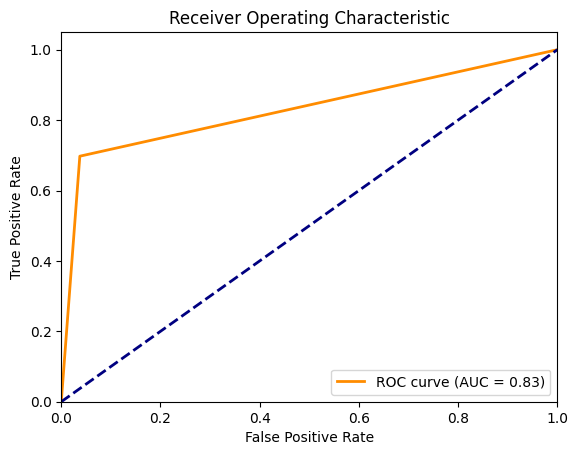

Results saved to sts_data_eval__mod_init_final.csv


In [15]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# -----------------------------
# SETTINGS
# -----------------------------
MODEL_PATH = './flaubert_informel'  # Path to your fine-tuned STS model
INPUT_FILE = 'sts_finetuning_dataset.csv'  # File containing sentence1 / sentence2
OUTPUT_FILE = 'sts_data_eval__mod_init_final.csv'   # Output file with annotated scores
MAX_LENGTH = 128
CLASSIFICATION_THRESHOLD = 3.0  # 3 as a threshold of similarity score for binary classification

# -----------------------------
# LOAD MODEL + TOKENIZER
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

# -----------------------------
# FUNCTION TO PREDICT STS SCORE
# -----------------------------
def get_predicted_score(sentence_a, sentence_b):
    """
    Predict similarity score between two sentences using fine-tuned model
    """
    inputs = tokenizer(
        str(sentence_a), 
        str(sentence_b),
        return_tensors='pt', 
        padding=True, 
        truncation=True, 
        max_length=MAX_LENGTH
    )
    # Move inputs to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    predicted_score = outputs.logits.item()
    return np.clip(predicted_score, 0.0, 5.0) 

# -----------------------------
# LOAD DATASET
# -----------------------------
print("Loading dataset...")
df = pd.read_csv(INPUT_FILE, sep=";", on_bad_lines='skip', encoding="utf-8")

# Ensure necessary columns exist and clean dataset
df.columns = df.columns.str.lower().str.strip()
if not {'sentence1', 'sentence2', 'similarity_score'}.issubset(df.columns):
    raise ValueError("Dataset must contain 'sentence1', 'sentence2', and 'similarity_score' columns")

df = df.dropna(subset=['sentence1', 'sentence2'])  # Remove rows with missing sentences

# -----------------------------
# GENERATE STS SCORES
# -----------------------------
print("Generating STS scores...")
predicted_continuous_scores = []

for index, row in df.iterrows():
    score = get_predicted_score(row['sentence1'], row['sentence2'])
    predicted_continuous_scores.append(score)

# -----------------------------
# BINARY CLASSIFICATION BASED ON THRESHOLD
# -----------------------------
true_scores = df['similarity_score'].tolist()

# Convert true and predicted scores into binary labels (1 = similar, 0 = not similar)
true_labels = (np.array(true_scores) >= CLASSIFICATION_THRESHOLD).astype(int)
predicted_labels = (np.array(predicted_continuous_scores) >= CLASSIFICATION_THRESHOLD).astype(int)

# -----------------------------
# CALCULATE METRICS
# -----------------------------

# Classification Metrics
f1 = f1_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)

# AUC and ROC curve
fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels)
auc_score = roc_auc_score(true_labels, predicted_labels)

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# -----------------------------
# PRINT RESULTS
# -----------------------------
print(f"Classification Metrics:")
print(f"F1 Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
print(f"ROC AUC: {auc_score:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")

# -----------------------------
# PLOT ROC CURVE
# -----------------------------
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# -----------------------------
# SAVE RESULTS WITH PROPER FORMATTING
# -----------------------------
df["similarity_score"] = predicted_continuous_scores  # Append predicted scores to dataframe
df[["sentence1", "sentence2", "similarity_score"]].to_csv(OUTPUT_FILE, sep=";", index=False, encoding="utf-8")

print(f"Results saved to {OUTPUT_FILE}")